In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

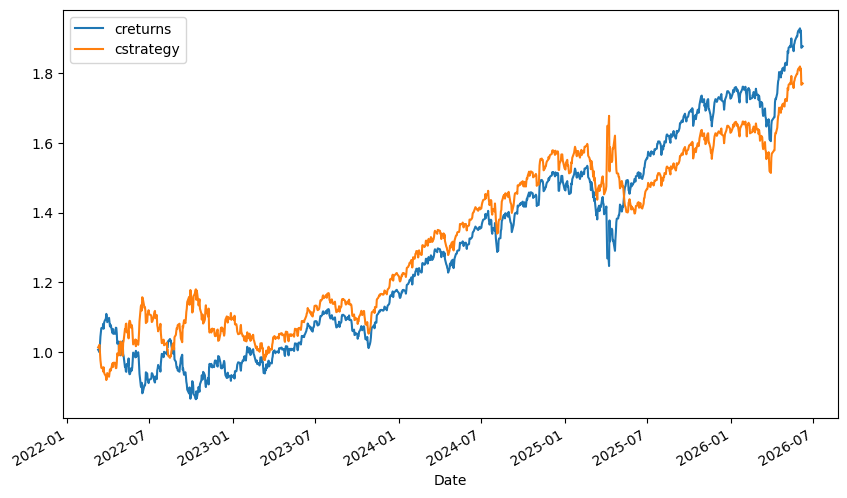

In [2]:
data=yf.Ticker('SPY')
df=data.history(period='5y')
df.head()
df=df[["Close"]]
df["Shifted Close"]=df["Close"].shift(1)
df["returns"]=np.log(df["Close"]/df["Shifted Close"])
df.dropna(inplace=True)
df["creturns"]=np.exp(df["returns"].cumsum())
df_copy=df.copy()
best_fit=[]

for i in range(10,60,5):
    for j in range(100,200,10):
        df_copy[f"{i}d"]=df_copy["Close"].rolling(i).mean()
        df_copy[f"{j}d"]=df_copy["Close"].rolling(j).mean()
        df_copy.dropna(inplace=True)
        df_copy["position"]=np.where(df_copy[f"{i}d"]>df_copy[f"{j}d"],1,-1)
        df_copy["strategy"]=df_copy["returns"]*df_copy["position"].shift(1)
        df_copy.dropna(inplace=True)
        df_copy["cstrategy"]=np.exp(df_copy["strategy"].cumsum())
        best_fit.append((i,j,df_copy["cstrategy"].iloc[-1]))
        df_copy = df.copy()
    
best_value=best_fit[0][2]
best_i=best_fit[0][0]
best_j=best_fit[0][1]
for i,j,value in best_fit:
    if value>best_value:
        best_value=value
        best_i=i
        best_j=j
        



df[f"{best_i}d"]=df["Close"].rolling(best_i).mean()
df[f"{best_j}d"]=df["Close"].rolling(best_j).mean()
df.dropna(inplace=True)
df["position"]=np.where(df[f"{best_i}d"]>df[f"{best_j}d"],1,-1)
df["strategy"]=df["returns"]*df["position"].shift(1)
df.dropna(inplace=True)
df["cstrategy"]=np.exp(df["strategy"].cumsum())
df[["creturns","cstrategy"]].plot(figsize=(10,6))
plt.show()











In [3]:

results_df = pd.DataFrame(best_fit, columns=['SMA_Short', 'SMA_Long', 'Final_Return'])
top_10 = results_df.sort_values(by='Final_Return', ascending=False).head(10)

print(top_10)

    SMA_Short  SMA_Long  Final_Return
49         30       190      1.770527
68         40       180      1.587643
98         55       180      1.564092
48         30       180      1.561550
58         35       180      1.560377
99         55       190      1.559627
67         40       170      1.541555
57         35       170      1.538555
76         45       160      1.530295
79         45       190      1.514437


Now seeing all the returns, we would not go for the (30,190) because it looks like an anomaly and we cannot base our algorithm solely off this so we would go for a timeframe which has a higher frequency in the top 10 and that is 180 so (40,180)acts as a good fit